In [1]:
%load_ext autoreload
%autoreload 2
!module load latex

In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import argparse
import numpy as np
import os
import sys

sys.path.append("../src")
from experiment_config import (
    ExperimentConfig,
    HypercubeConfig,
    HilbertConfig,
    SamplerConfig,
    J1J2Config,
    ViT2DConfig,
    ConstantSchedule,
    CosineDecaySchedule,
    OptimizerConfig,
    SRConfig,
)
from new_logger import CheckpointCallback
import netket as nk
import matplotlib

∣NK⟩ Tip: If timeit=True signals high \% spent sampling n_discarded, consider lowering it.

In [3]:
folder = "data/HEG/"
res_plain = np.load(folder+ "rs0p5_n45_pol_real_mk2_lr1em3_clip0/variance_sample_step9999/rs0p5_n45_pol_real_mk2_lr1em3_seed42_ckpt9999_plain_ss512_steps10000.npz",allow_pickle=True)
eloc_plain = res_plain["eloc"]
var_plain = (eloc_plain - np.mean(eloc_plain))**2

res_blur_q0p5 = np.load(folder+ "rs0p5_n45_pol_real_mk2_lr1em3_clip0/variance_sample_step9999/rs0p5_n45_pol_real_mk2_lr1em3_seed42_ckpt9999_blur_q0p5_eps1p0_ss512_steps10000.npz",allow_pickle=True)
w = res_blur_q0p5["raw_weight"]
eloc = res_blur_q0p5["eloc"]
var_blur_q0p5 = w * (eloc-np.mean(w*eloc))**2

/tmp/ipykernel_1032692/3377106072.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_2.legend(frameon = False, fontsize = 14,loc="upper center")


A = 1.6016010113713752


/tmp/ipykernel_1032692/3377106072.py:238: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_2.set_ylim(0.0,0.02)


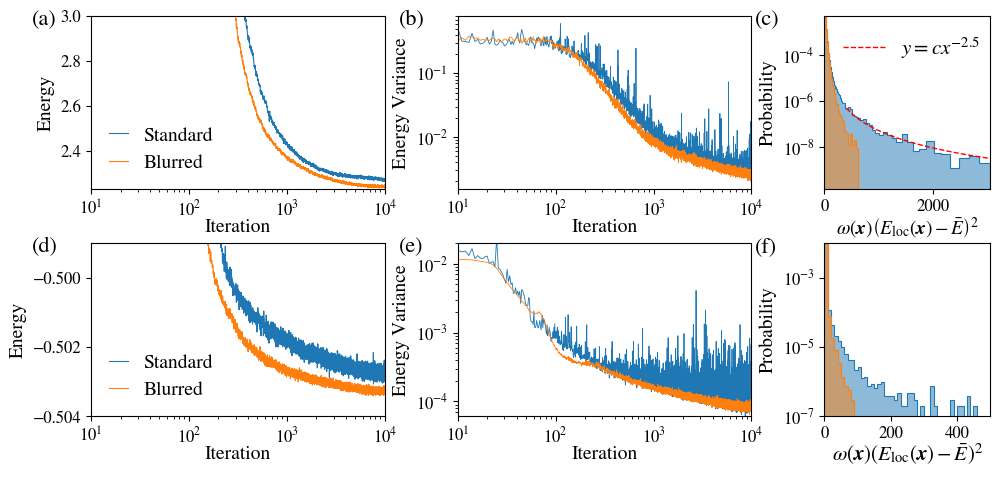

In [4]:
# Create figure with 2x2 subplots
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from matplotlib.colors import to_rgba
c_plain = plt.get_cmap("tab10")(0)
c_q03   = plt.get_cmap("tab10")(2)
c_q05   = plt.get_cmap("tab10")(1)

color_hist = {0.0: c_plain, 0.3: c_q03,0.5: c_q05}

fig = plt.figure(figsize=(11.6, 5.2), constrained_layout=False)
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1], width_ratios=[0.8,0.8,0.8,0.8,1.2], wspace=0.6, hspace=0.31)

ax_1 = fig.add_subplot(gs[0, :2])  
ax_2 = fig.add_subplot(gs[0, 2:4])   
ax_3 = fig.add_subplot(gs[0, 4])    

mk = 2
data_blur_42 = np.loadtxt(folder+f"rs0p5_n45_pol_real_mk{mk}_lr1em3_clip0/seed42_blur_q0p5/data.txt")
data_plain_42 = np.loadtxt(folder+f"rs0p5_n45_pol_real_mk{mk}_lr1em3_clip0/seed42_plain/data.txt")
cut= 10000
ax_1.plot(np.arange(len(data_plain_42[:cut,3])),(data_plain_42[:cut,3])/45,lw=0.8,label="Standard")
ax_1.plot(np.arange(len(data_blur_42[:cut,4])),(data_blur_42[:cut,4])/45,lw=0.8,label=r"Blurred")

idx=500

c0 = plt.get_cmap("tab10")(0)
c1 = plt.get_cmap("tab10")(1)
y0 = data_plain_42[:cut, 6] / 45**2
y1 = data_blur_42[:cut, 9] * data_blur_42[:cut, 7]**2 / 45**2

# raw data: 浅色
ax_2.plot(y0, color=c0, alpha=1.0, lw=0.6)
ax_2.plot(y1, color=c1, alpha=1.0, lw=0.6)

ax_1.set_xlabel("Iteration", fontsize = 14,labelpad=0)
ax_2.set_xlabel("Iteration", fontsize = 14,labelpad=0)

ax_1.legend(frameon = False, fontsize = 14,loc="lower left", handlelength=1.0)
ax_2.legend(frameon = False, fontsize = 14,loc="upper center")

ax_1.set_ylim(2.23, 3) 

ax_1.set_ylabel(r"Energy",fontsize = 14)
ax_2.set_ylabel(r"Energy Variance",fontsize = 14)

ax_2.set_yscale("log")



bins = 100
xmin_fit, xmax_fit = 0.7*45**2, 1.5*45**2
p = 2.5

hist, edges = np.histogram(var_plain, bins=bins, range=(0, 20*45**2), density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

# fit only the tail region
mask = (centers >= xmin_fit) & (centers <= xmax_fit) & (hist > 0)
x = centers[mask]
y = hist[mask]

# least-squares fit for A in y ≈ A * x^{-p}
phi = x**(-p)
A = np.dot(y, phi) / np.dot(phi, phi)

print("A =", A)

from matplotlib.colors import to_rgba
c_plain = plt.get_cmap("tab10")(0)
c_q05   = plt.get_cmap("tab10")(1)
c_q08   = plt.get_cmap("tab10")(2)

bins_small = np.linspace(0, 0.1*45**2, 50)      
bins_large = np.geomspace(0.1*45**2, 1.5*45**2, 40) 
bins = np.unique(np.concatenate([bins_small, bins_large]))

ax_3.hist(var_plain, bins, [0, 1.5*45**2],
          density=True, histtype='stepfilled',
          facecolor=to_rgba(c_plain, 0.50),
          edgecolor=c_plain, linewidth=0.8)

ax_3.hist(var_blur_q0p5, bins, [0, 1.5*45**2],
          density=True, histtype='stepfilled',
          facecolor=to_rgba(c_q05, 0.50),
          edgecolor=c_q05, linewidth=0.8)

xx = np.arange(0.2*45**2, 1.5*45**2,0.001)
ax_3.plot(xx, A * xx**(-p), 'r--',lw=1, label=r"$y = c x^{-2.5}$")

ax_3.set_yscale("log")

ax_3.set_xlabel(r"$\omega(\boldsymbol{x})\left(E_\text{loc}(\boldsymbol{x})-\bar{E} \right)^2$",fontsize=14,labelpad=0)
ax_3.set_ylabel(r"Probability",fontsize=14)
ax_3.set_ylim(3e-7/45**2,10/45**2)
ax_3.set_xlim(0,1.5*45**2)
ax_3.legend(frameon=False, fontsize=15)


loc_x = -0.2
loc_y = 0.95
fs = 16
ax_1.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_2.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_3.annotate("(c)", xy=(2.1*loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_1.tick_params(axis='both', which='major', labelsize=12)
ax_2.tick_params(axis='both', which='major', labelsize=12)
ax_3.tick_params(axis='both', which='major', labelsize=12)

for ax in [ax_1,ax_2]:
    ax.set_xscale("log")
    ax.set_xlim(10, 10000)



ax_1 = fig.add_subplot(gs[1, :2])  
ax_2 = fig.add_subplot(gs[1, 2:4])   
ax_3 = fig.add_subplot(gs[1, 4])    


CSs = {
    2: {2**14: 2**13},
    4: {2**14: 4096},
}
num_layers = 2
x_min = 10
ylim_vscore = {2: (2e-2, 5e-2), 4: (1e-2, 5e-2)}
ylim_mean = {2: (-0.5039, -0.50), 4: (-0.5039, -0.50)}
ylim_var = {2: (5e-3, 3e-1), 4: (5e-3, 3e-1)}
L = 6
ns = 2**14

for i, q in enumerate([0.0, 0.5]):
    # Configuration dictionary
    config = {
        "ns": ns,
        "patch_size": 3,
        "num_layers": num_layers,
        "d_model": 72,
        "heads": 12,
        "L": L,
        "seed": 100,
        "experiment_name": "June18",
        "diag_shift": 1e-3,
        "lr": 0.01,
        "thermalizing_steps": 0,
        "chunk_size": CSs[num_layers][ns],
        "auto_tune_lr": False,
        "q_blur": q,
    }

    # Convert to namespace for compatibility with get_data
    args = argparse.Namespace(**config)
    lattice_cfg = HypercubeConfig(L=args.L, max_neighbor_order=2)
    hilbert_cfg = HilbertConfig(total_sz=0)
    system_cfg = J1J2Config(sign_rule=None)
    sampler_cfg = SamplerConfig(q_blur=args.q_blur)
    model_cfg = ViT2DConfig(
        patch_size=args.patch_size,
        num_layers=args.num_layers,
        d_model=args.d_model,
        heads=args.heads,
    )

    diag_shift_cfg = ConstantSchedule(args.diag_shift)
    lr_init = args.lr
    lr_cfg = CosineDecaySchedule(lr_init, 10000, lr_init / 10)
    variance_scaled = getattr(args, "variance_scaled", False)
    optimizer_cfg = OptimizerConfig(
        lr=lr_cfg, diag_shift=diag_shift_cfg, variance_scaled=variance_scaled
    )
    chunk_size = getattr(args, "chunk_size", None)
    momentum = getattr(args, "momentum", False)

    sr_cfg = SRConfig(chunk_size=chunk_size, momentum=momentum)

    config = ExperimentConfig(
        seed=args.seed,
        n_samples=args.ns,
        n_steps=10000,
        thermalize_steps=args.thermalizing_steps,
        root="./data",
        name=args.experiment_name,
        lattice=lattice_cfg,
        hilbert=hilbert_cfg,
        hamiltonian=system_cfg,
        sampler=sampler_cfg,
        model=model_cfg,
        optimizer=optimizer_cfg,
        sr=sr_cfg,
    )
    save_path = config.save_path()

    ckpt = CheckpointCallback(
        save_path, logger=nk.logging.RuntimeLog(), every_n_steps=25, wandb_run=False
    )
    logger, restored = ckpt.restore_logger()
    E = np.load(save_path + f"blurred_local_energies_q{q:1.1f}.npy").flatten()
    w = np.load(save_path + f"blurred_importance_weights_q{q:1.1f}.npy").flatten()
    # Extract energy data
    N = L**2
    energies_mean = np.array(logger.data["Energy"]["Mean"]).real / (4 * N)
    energies_variance = np.array(logger.data["Energy"]["Variance"]).real / (4 * N)**2
    energies_w_variance = np.array(logger.data["weighted_variance"]).real / (4 * N)**2
    try:
        ess_values = np.array(logger.data["ess"])
    except KeyError:
        ess_values = np.array([np.nan])

    try:
        accept_values = np.array(logger.data["acceptance"])
    except KeyError:
        accept_values = np.array([np.nan])

    # Mean energy (top left, zoomed convergence)
    ax = ax_1
    label_q = "Standard" if q==0.0 else rf"Blurred"
    ax.plot(energies_mean, label=label_q, alpha=1.0,lw=0.8)
    ax.set_xlabel("Step", fontsize=15)
    ax.set_ylim(-0.504,-0.499)
    ax.set_xlim(x_min, 10000)
    ax.set_xscale("log")
    ax.set_ylabel("Energy", fontsize=14)
    ax.legend(frameon=False, fontsize=14, handlelength=1.0)

    # Energy Variance (top right)
    ax_2.plot(
        energies_w_variance,
        alpha=1.0, lw=0.6
    )
    ax_2.set_xlabel("Step", fontsize=14)
    ax_2.set_xscale("log")
    ax_2.set_ylabel("Energy Variance", fontsize=14)

    ax_2.set_ylim(0.0,0.02)
    ax_2.set_yscale("log")
    ax_2.set_xlim(x_min, 10000)
    # Variance
    w = w / np.mean(w)
    MeanE = np.mean(w * E).real
    Z = w * np.abs(E - MeanE) ** 2/16
    
    ax_3.hist(Z,bins=50,range=(0, 500),
          density=True, histtype='stepfilled',
          facecolor=to_rgba(color_hist[q], 0.50),
          edgecolor=color_hist[q], linewidth=0.8)
    
    ax_3.set_yscale("log")
    ax_3.set_xlabel(
        r"$\omega(\boldsymbol{x}) (E_{\mathrm{loc}}(\boldsymbol{x}) - \bar E)^2$",
        fontsize=15,labelpad=0
    )
    ax_3.set_ylabel("Probability", fontsize=14)
    ax_3.set_xlim(0,500)
    ax_3.set_ylim(10**-7 , 10**-2)
    # Effective Sample Size (bottom left)
    if q == 0:
        continue

loc_x = -0.2
loc_y = 0.95
fs = 16

ax_1.set_xlabel("Iteration", fontsize = 14,labelpad=0)
ax_2.set_xlabel("Iteration", fontsize = 14,labelpad=0)

ax_1.annotate("(d)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_2.annotate("(e)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_3.annotate("(f)", xy=(2.1*loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_1.tick_params(axis='both', which='major', labelsize=12)
ax_2.tick_params(axis='both', which='major', labelsize=12)
ax_3.tick_params(axis='both', which='major', labelsize=12)

plt.savefig("Fig8.pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()